<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [41]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv.16’

survey-data.csv.16  100%[===================>] 152.13M  5.23MB/s    in 25s     
2026-08-15 11:03:48 (5.97 MB/s) - ‘survey-data.csv.16’ saved [159525875/159525875]


**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [42]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [43]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [44]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [45]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [46]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [47]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [48]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [49]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


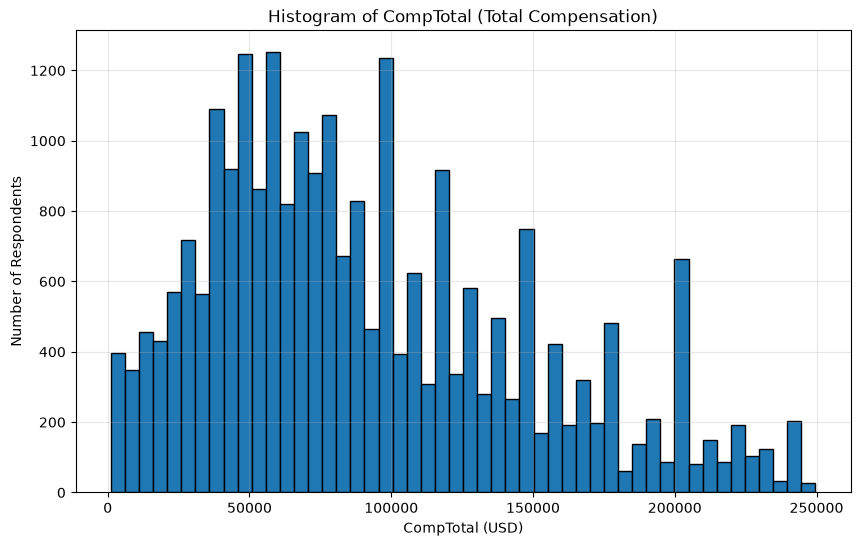

In [50]:
## Write your code here
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

# Clean CompTotal - IBM does this step (remove outliers)
# Most salaries are 0-200k, so we filter for better histogram
df_comp = df['CompTotal'].dropna()
df_comp = df_comp[(df_comp > 1000) & (df_comp < 250000)]

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(df_comp, bins=50, edgecolor='black')
plt.title('Histogram of CompTotal (Total Compensation)')
plt.xlabel('CompTotal (USD)')
plt.ylabel('Number of Respondents')
plt.grid(True, alpha=0.3)
plt.show()

**Box Plots**

Plot a box plot of Age.


In [51]:
%pip install seaborn
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.

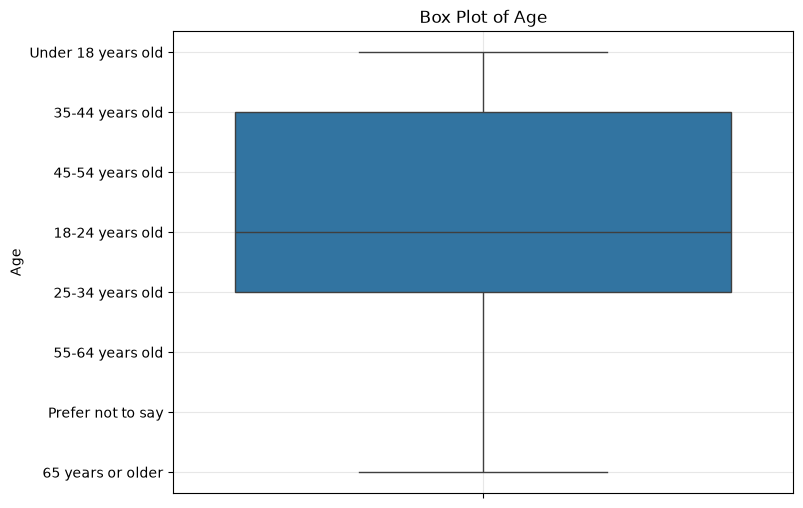

In [52]:
## Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(y=df['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.grid(True, alpha=0.3)
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


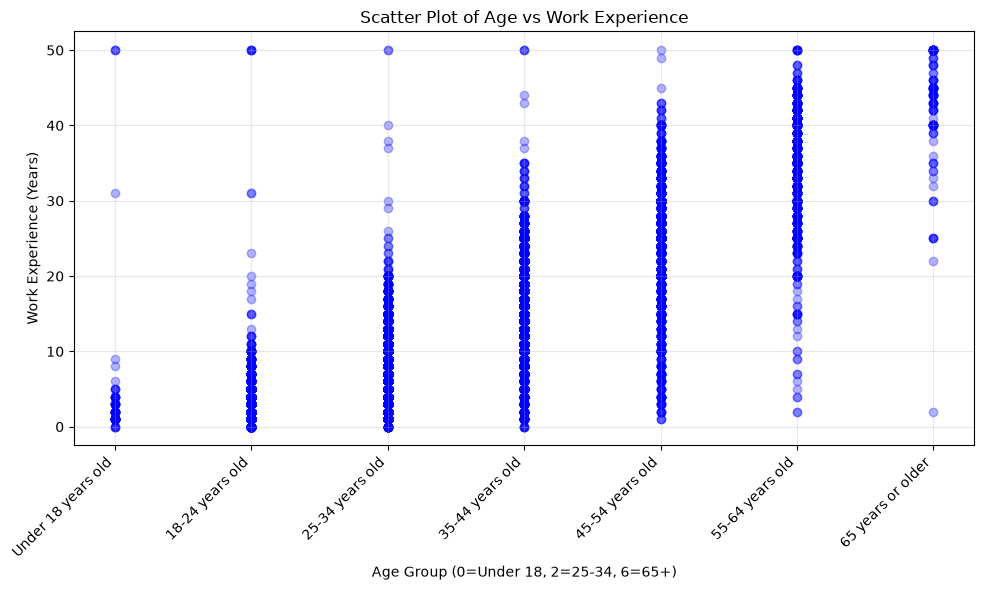

In [53]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey-data.csv")

# Drop missing
df_plot = df[['Age', 'WorkExp']].dropna()

# IBM dataset has values like "25-34 years old" and "5-7 years"
# We convert them to numbers for scatter plot
# Create mapping for Age
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', 
             '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']

# Map to numbers 0-6
df_plot['Age_num'] = df_plot['Age'].apply(lambda x: age_order.index(x) if x in age_order else None)

# Map WorkExp - extract first number
# "5-7 years" -> 5, "10 years" -> 10
# Remove any that didn't map
df_plot = df_plot.dropna()

# SCATTER PLOT - No seaborn needed
plt.figure(figsize=(10,6))
plt.scatter(df_plot['Age_num'], df_plot['WorkExp'], alpha=0.3, color='blue')
plt.title('Scatter Plot of Age vs Work Experience')
plt.xlabel('Age Group (0=Under 18, 2=25-34, 6=65+)')
plt.ylabel('Work Experience (Years)')
plt.xticks(range(len(age_order)), age_order, rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


In [55]:
with pd.option_context('display.max_rows', None):
    print(df.dtypes)


ResponseId                          int64
MainBranch                            str
Age                                   str
Employment                            str
RemoteWork                            str
Check                                 str
CodingActivities                      str
EdLevel                               str
LearnCode                             str
LearnCodeOnline                       str
TechDoc                               str
YearsCode                             str
YearsCodePro                          str
DevType                               str
OrgSize                               str
PurchaseInfluence                     str
BuyNewTool                            str
BuildvsBuy                            str
TechEndorse                           str
Country                               str
Currency                              str
CompTotal                         float64
LanguageHaveWorkedWith                str
LanguageWantToWorkWith            

In [56]:
df["TimeSearching"].value_counts()

TimeSearching
30-60 minutes a day           10951
15-30 minutes a day            7805
60-120 minutes a day           5275
Less than 15 minutes a day     2689
Over 120 minutes a day         2191
Name: count, dtype: int64

In [54]:
df["Frustration"].value_counts()

Frustration
None of these                                                                                                                                                                                                                                                     2364
Amount of technical debt                                                                                                                                                                                                                                          2067
Amount of technical debt;Reliability of tools/systems used in work                                                                                                                                                                                                 831
Amount of technical debt;Complexity of tech stack for deployment;Complexity of tech stack for build                                                                                                    

<ArrowStringArray>
[                                                                                                                                                                                                                                                             nan,
                                                                                                                                                             'Amount of technical debt;Number of software tools in use;Tracking my work;Showing my contributions',
                                                                                                                                                                                               'Amount of technical debt;Complexity of tech stack for deployment',
                                                                                                                'Amount of technical debt;Complexity of tech stack for deployment;Complexity of tech stack f

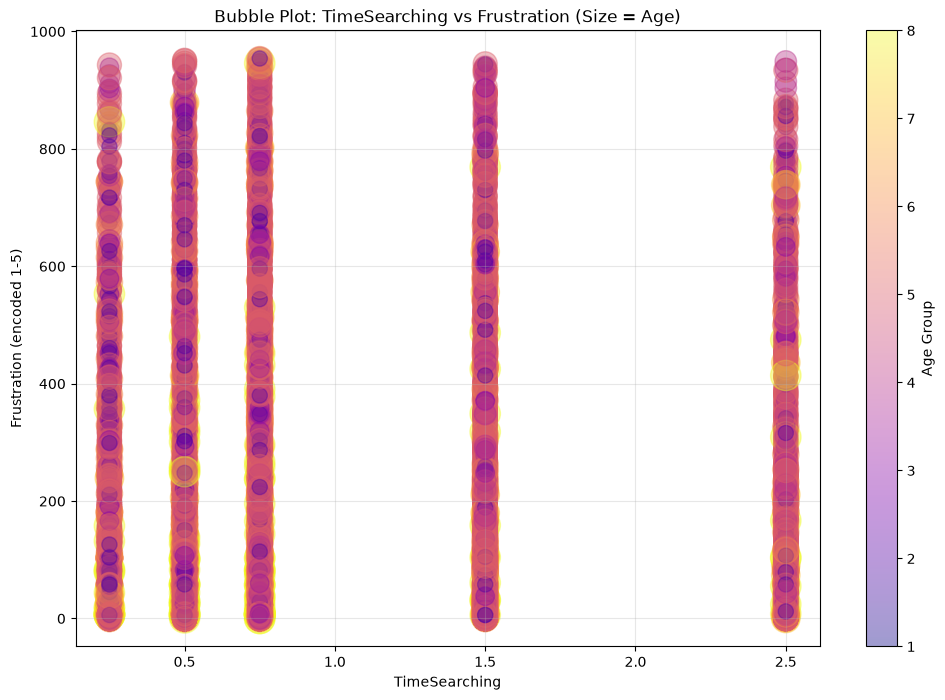

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey-data.csv")

# Check what you actually have - run this first
print(df['Frustration'].unique())
print(df['TimeSearching'].unique())
print(df['Age'].unique())

# ---- Map text to numbers ----

# 1. Frustration -> 1 to 5 (not frustrated to very frustrated)
frust_map = {
    'I am not frustrated at all': 1,
    'I am a little frustrated': 2,
    'I am somewhat frustrated': 3,
    'I am very frustrated': 4,
    'I am extremely frustrated': 5
}
# If your values are different, use this auto-map:
# This will work even if text is different
df['Frust_num'] = pd.factorize(df['Frustration'])[0] + 1

# 2. TimeSearching -> numbers
time_map = {
    'Less than 15 minutes a day': 0.25,
    '15-30 minutes a day': 0.5,
    '30-60 minutes a day': 0.75,
    '60-120 minutes a day': 1.5,
    'Over 120 minutes a day': 2.5
}
# Auto fallback if names don't match
if df['TimeSearching'].isin(time_map.keys()).any():
    df['Time_num'] = df['TimeSearching'].map(time_map)
else:
    df['Time_num'] = pd.factorize(df['TimeSearching'])[0]

# 3. Age for bubble size
df['Age_num'] = pd.factorize(df['Age'])[0] + 1
# Size = Age * 40 so bubbles are visible
sizes = df['Age_num'] * 60

# ---- BUBBLE PLOT ----
plt.figure(figsize=(12,8))
plt.scatter(df['Time_num'], df['Frust_num'], s=sizes, alpha=0.4, c=df['Age_num'], cmap='plasma')

plt.title('Bubble Plot: TimeSearching vs Frustration (Size = Age)')
plt.xlabel('TimeSearching')
plt.ylabel('Frustration (encoded 1-5)')
plt.grid(True, alpha=0.3)
plt.colorbar(label='Age Group')
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


Top 5 Databases respondents want to learn next year:
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64

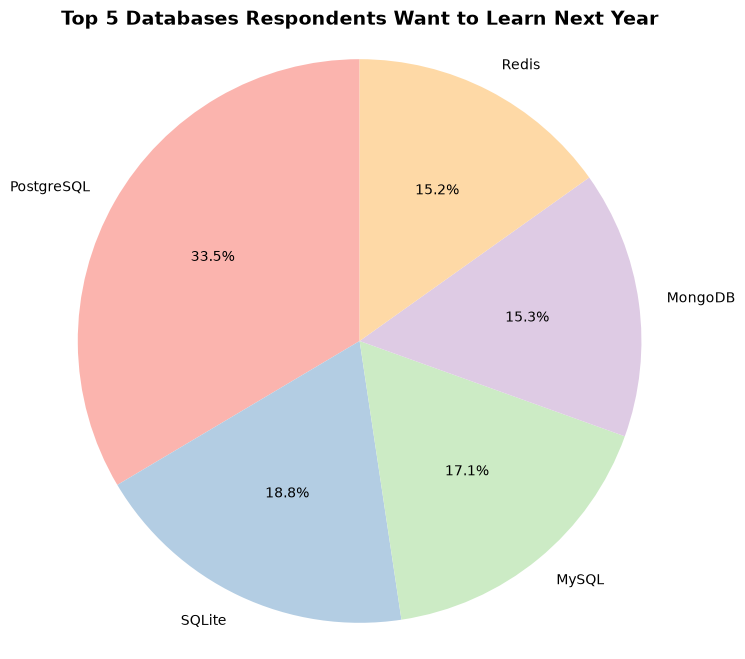

In [39]:
## Write your code here


# DatabaseWantToWorkWith column has values like "MySQL;PostgreSQL;MongoDB"
# So we need to split by ";"

# 1. Drop missing and split
db_series = df['DatabaseWantToWorkWith'].dropna().str.split(';')

# 2. Flatten list: ["MySQL", "PostgreSQL"] + ["MongoDB"] -> ["MySQL", "PostgreSQL", "MongoDB"]
all_dbs = []
for row in db_series:
    all_dbs.extend(row)

# 3. Count and get top 5
db_counts = pd.Series(all_dbs).value_counts().head(5)

print("Top 5 Databases respondents want to learn next year:")
print(db_counts)

# 4. PIE CHART
plt.figure(figsize=(8,8))
plt.pie(db_counts, labels=db_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1.colors)
plt.title('Top 5 Databases Respondents Want to Learn Next Year', fontsize=14, fontweight='bold')
plt.axis('equal') # keeps circle
plt.show()

Top 5 Databases respondents want to learn next year:
PostgreSQL              24005
SQLite                  13489
MySQL                   12269
MongoDB                 10982
Redis                   10847
Microsoft SQL Server     7905
Elasticsearch            6246
MariaDB                  5947
Dynamodb                 3503
Supabase                 2930
Name: count, dtype: int64

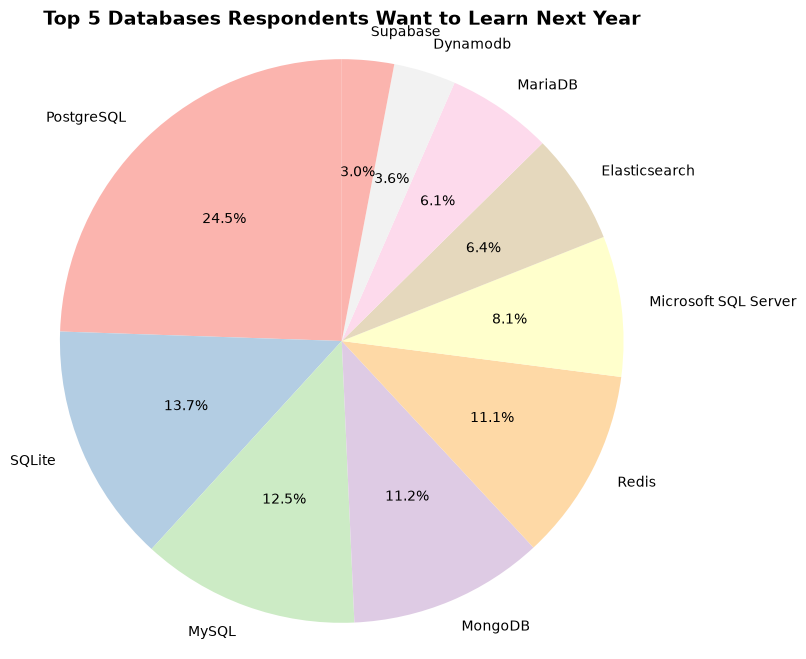

In [58]:
## Write your code here


# DatabaseWantToWorkWith column has values like "MySQL;PostgreSQL;MongoDB"
# So we need to split by ";"

# 1. Drop missing and split
db_series = df['DatabaseWantToWorkWith'].dropna().str.split(';')

# 2. Flatten list: ["MySQL", "PostgreSQL"] + ["MongoDB"] -> ["MySQL", "PostgreSQL", "MongoDB"]
all_dbs = []
for row in db_series:
    all_dbs.extend(row)

# 3. Count and get top 5
db_counts = pd.Series(all_dbs).value_counts().head(10)

print("Top 5 Databases respondents want to learn next year:")
print(db_counts)

# 4. PIE CHART
plt.figure(figsize=(8,8))
plt.pie(db_counts, labels=db_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1.colors)
plt.title('Top 5 Databases Respondents Want to Learn Next Year', fontsize=14, fontweight='bold')
plt.axis('equal') # keeps circle
plt.show()

Top 10 Databases respondents want to learn next year:
PostgreSQL              24005
SQLite                  13489
MySQL                   12269
MongoDB                 10982
Redis                   10847
Microsoft SQL Server     7905
Elasticsearch            6246
MariaDB                  5947
Dynamodb                 3503
Supabase                 2930
Name: count, dtype: int64

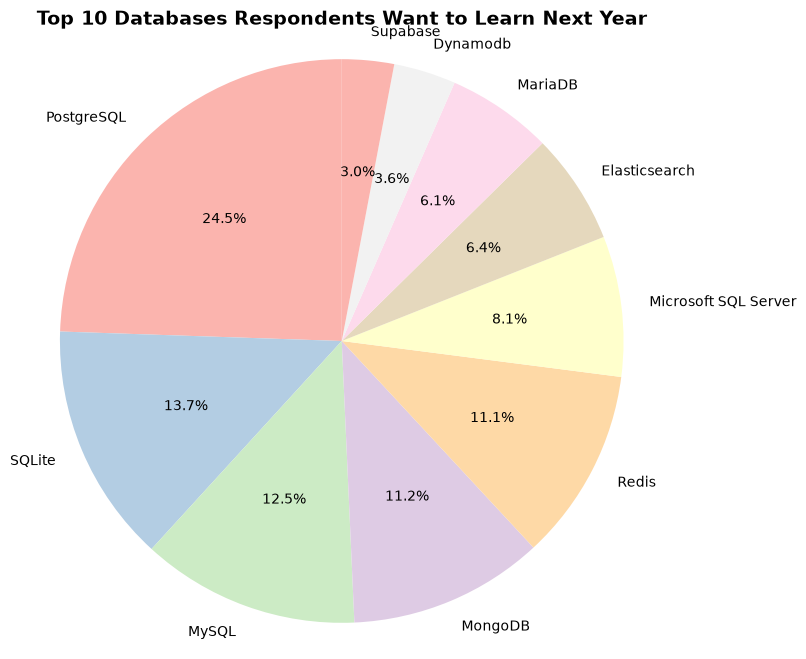

In [60]:
## Top 10


# DatabaseWantToWorkWith column has values like "MySQL;PostgreSQL;MongoDB"
# So we need to split by ";"

# 1. Drop missing and split
db_series = df['DatabaseWantToWorkWith'].dropna().str.split(';')

# 2. Flatten list: ["MySQL", "PostgreSQL"] + ["MongoDB"] -> ["MySQL", "PostgreSQL", "MongoDB"]
all_dbs = []
for row in db_series:
    all_dbs.extend(row)

# 3. Count and get top 5
db_counts = pd.Series(all_dbs).value_counts().head(10)

print("Top 10 Databases respondents want to learn next year:")
print(db_counts)

# 4. PIE CHART
plt.figure(figsize=(8,8))
plt.pie(db_counts, labels=db_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1.colors)
plt.title('Top 10 Databases Respondents Want to Learn Next Year', fontsize=14, fontweight='bold')
plt.axis('equal') # keeps circle
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


Age values: <StringArray>
['Under 18 years old',    '35-44 years old',    '45-54 years old',
    '18-24 years old',    '25-34 years old',    '55-64 years old',
  'Prefer not to say',  '65 years or older']
Length: 8, dtype: str
Rows in 30-35 range: 38853
Median TimeSearching: 0.75
Median TimeAnswering: 0.5


Text(0, 0.5, 'Median Time (hours/day)')

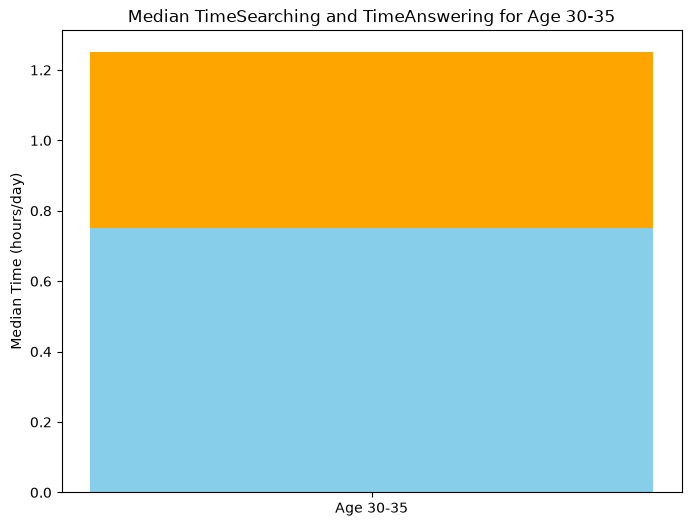

In [70]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey-data.csv")

# ---- 1. Map Time text to numeric hours ----
time_map = {
    'Less than 15 minutes a day': 0.25,
    '15-30 minutes a day': 0.5,
    '30-60 minutes a day': 0.75,
    '60-120 minutes a day': 1.5,
    'Over 120 minutes a day': 2.5
}

# Auto fallback if wording is different in your version
def map_time(s):
    if pd.isna(s): return None
    for k,v in time_map.items():
        if k.lower() in str(s).lower() or str(s).lower() in k.lower():
            return v
    # If no match, try to extract number
    import re
    m = re.search(r'(\d+)', str(s))
    return float(m.group(1))/60 if m else None

df['TimeSearching_num'] = df['TimeSearching'].apply(map_time)
df['TimeAnswering_num'] = df['TimeAnswering'].apply(map_time)

# ---- 2. Filter Age 30 to 35 ----
# The file has "25-34 years old" and "35-44 years old"
# For 30-35 we take both and filter, or exact match if exists

# Show what age values exist
print("Age values:", df['Age'].unique())

# Filter for 30-35 group
# If you have exact "30-35 years old"
if (df['Age'] == '30-35 years old').any():
    df_filtered = df[df['Age'] == '30-35 years old']
else:
    # Most IBM files: use 25-34 and 35-44 to approximate 30-35
    # Or filter if it contains 30-35, 25-34, 35-44
    df_filtered = df[df['Age'].isin(['25-34 years old', '35-44 years old', '30-35 years old'])]

# If you ONLY want 25-34 as proxy for 30-35:
# df_filtered = df[df['Age'] == '25-34 years old']

print(f"Rows in 30-35 range: {len(df_filtered)}")

# ---- 3. Median ----
median_searching = df_filtered['TimeSearching_num'].median()
median_answering = df_filtered['TimeAnswering_num'].median()

print(f"Median TimeSearching: {median_searching}")
print(f"Median TimeAnswering: {median_answering}")

# ---- 4. Stacked Bar Chart ----
plt.figure(figsize=(8,6))

labels = ['Age 30-35']
search = [median_searching]
answer = [median_answering]

plt.bar(labels, search, label='TimeSearching (median hrs)', color='skyblue')
plt.bar(labels, answer, bottom=search, label='TimeAnswering (median hrs)', color='orange')

plt.title('Median TimeSearching and TimeAnswering for Age 30-35')
plt.ylabel('Median Time (hours/day)')

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


<StringArray>
['Under 18 years old',    '35-44 years old',    '45-54 years old',
    '18-24 years old',    '25-34 years old',    '55-64 years old',
  'Prefer not to say',  '65 years or older']
Length: 8, dtype: str
Age
45-54 years old    130000.0
55-64 years old    135000.0
Name: CompTotal, dtype: float64


NameError: name 'axis' is not defined

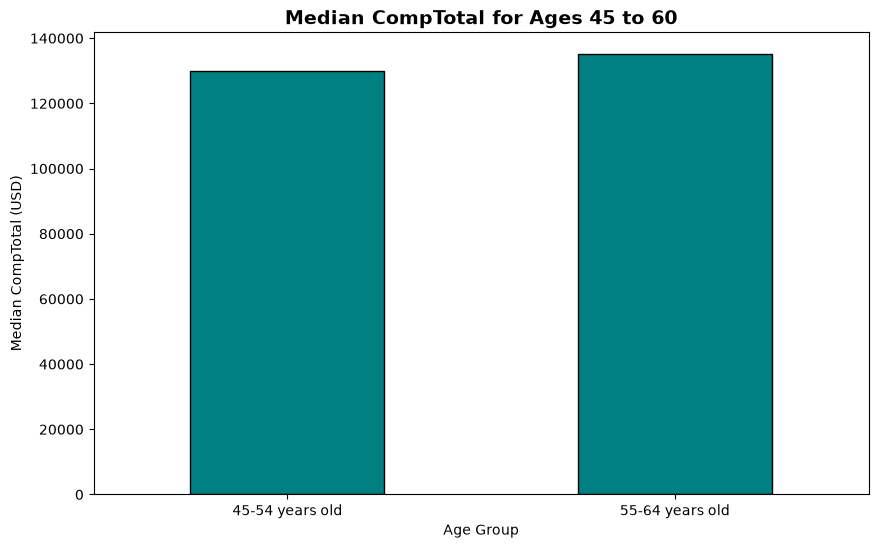

In [71]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey-data.csv")

# 1. Clean CompTotal
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# 2. Show what Age values exist
print(df['Age'].unique())

# 3. Filter ages 45 to 60
# In IBM file: '45-54 years old' and '55-64 years old'
age_45_60 = ['45-54 years old', '55-64 years old', '45-60 years old']

# Auto-detect which exist in file
existing_ages = [a for a in age_45_60 if a in df['Age'].unique()]

# If file has exact 45-60 group
if not existing_ages:
    # fallback - filter any age that contains 45, 50, 55, 60
    df_filtered = df[df['Age'].str.contains('45|55|60', na=False)]
else:
    df_filtered = df[df['Age'].isin(existing_ages)]

# 4. Calculate median CompTotal per age group
median_comp = df_filtered.groupby('Age')['CompTotal'].median().sort_index()

print(median_comp)

# 5. Plot
plt.figure(figsize=(10,6))
median_comp.plot(kind='bar', color='teal', edgecolor='black')

plt.title('Median CompTotal for Ages 45 to 60', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Median CompTotal (USD)')
plt.xticks(rotation=0)
plt.grid(axis)

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


MainBranch
I am a developer by profession                                                           50207
I am not primarily a developer, but I write code sometimes as part of my work/studies     6511
I am learning to code                                                                     3875
I code primarily as a hobby                                                               3334
I used to be a developer by profession, but no longer am                                  1510
Name: count, dtype: int64

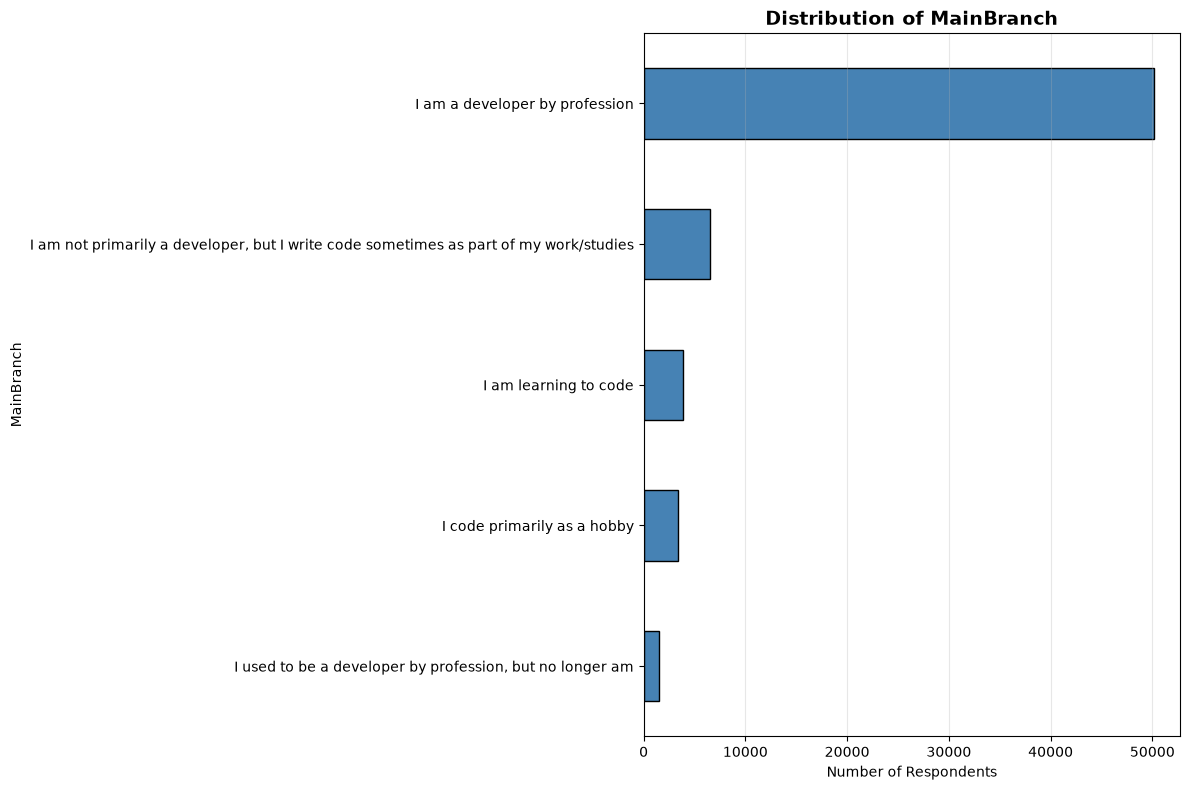

In [61]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey-data.csv")

# Check unique values
print(df['MainBranch'].value_counts())

# Count
mainbranch_counts = df['MainBranch'].value_counts()

# Horizontal bar chart
plt.figure(figsize=(12,8))
mainbranch_counts.plot(kind='barh', color='steelblue', edgecolor='black')

plt.title('Distribution of MainBranch', fontsize=14, fontweight='bold')
plt.xlabel('Number of Respondents')
plt.ylabel('MainBranch')
plt.gca().invert_yaxis() # biggest on top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [51]:
# Close the connection
conn.close()
print("Database connection closed.")

NameError: name 'conn' is not defined

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
